# 🏠 Previsão de Preços de Imóveis com o Dataset Ames Housing

Este projeto tem como objetivo prever o valor de venda de casas residenciais usando o dataset Ames Housing. Vamos aplicar técnicas de regressão, como Regressão Linear e Random Forest, além de explorar o tratamento de variáveis categóricas, normalização e seleção de atributos.

---


In [50]:
# 📚 Importações principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurar estilo dos gráficos
sns.set(style="whitegrid")
%matplotlib inline


In [52]:
# 📥 Carregar o dataset Ames Housing
df = pd.read_csv('AmesHousing.csv')

# 👀 Visualizar as 5 primeiras linhas
df.head()


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 📊 Entendimento do Dataset

O dataset **Ames Housing** contém informações detalhadas sobre imóveis residenciais vendidos em Ames, Iowa. Cada linha representa uma casa, e cada coluna representa uma característica (feature), como número de quartos, área construída, ano de construção, tipo de telhado, entre outras.

Nosso objetivo é prever a variável **`SalePrice`**, que representa o preço de venda da casa.

Vamos começar explorando as dimensões, tipos de dados e estatísticas básicas do conjunto.


#### Dimensões e informações básicas

In [54]:
# 🔢 Verificar o número de linhas e colunas
df.shape


(2930, 82)

In [56]:
# 🧾 Ver os tipos de dados e colunas nulas
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [13]:
# 📈 Estatísticas descritivas
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


## ❗ Análise de Valores Ausentes

Antes de aplicar qualquer modelo, precisamos verificar se o dataset possui **valores ausentes (missing values)**. Valores ausentes podem afetar negativamente o desempenho dos algoritmos de Machine Learning, e por isso é necessário tratá-los corretamente.

Vamos identificar as colunas com dados faltantes e analisar a porcentagem de ausência para decidir como tratá-los.


#### Identificação de valores ausentes

In [58]:
# 🔍 Total de valores ausentes por coluna
missing_values = df.isnull().sum()

# 📉 Porcentagem de valores ausentes
missing_percentage = (missing_values / len(df)) * 100

# 🧾 Juntar tudo em um DataFrame para melhor visualização
missing_data = pd.DataFrame({
    'Total Ausentes': missing_values,
    '% Ausente': missing_percentage
})

# 📋 Mostrar apenas as colunas com pelo menos 1 valor ausente, ordenado do maior para o menor
missing_data = missing_data[missing_data['Total Ausentes'] > 0].sort_values(by='% Ausente', ascending=False)
missing_data


,Total Ausentes,% Ausente
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423
Lot Frontage,490,16.723549
Garage Cond,159,5.426621
Garage Qual,159,5.426621
Garage Finish,159,5.426621


## 📦 Tratamento dos valores ausentes

#### 🧹 Remoção de colunas com muitos valores ausentes e baixa relevância

In [60]:
# Remover colunas com mais de 80% de valores ausentes e baixa relevância preditiva
df.drop(['Pool QC', 'Misc Feature', 'Alley', 'Fence'], axis=1, inplace=True)


#### 🧩 Preencher ausências com 'None'

In [62]:
# Preencher com 'None' onde a ausência indica que o imóvel não possui o item
cols_none = ['Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
             'Garage Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
             'Bsmt Qual', 'Bsmt Cond']

for col in cols_none:
    df[col] = df[col].fillna('None')

# Preencher Garage Yr Blt com 0 (ausência de garagem)
df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0)


#### 📏 Preencher Lot Frontage com mediana por vizinhança

In [64]:
# Preencher Lot Frontage com a mediana por vizinhança
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(
    lambda x: x.fillna(x.median()))


#### 📊 Preencher com moda ou 0 conforme o caso

In [66]:
# Mas Vnr Type com moda (valor mais comum)
df['Mas Vnr Type'] = df['Mas Vnr Type'].fillna(df['Mas Vnr Type'].mode()[0])

# Mas Vnr Area com 0
df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna(0)

# Electrical com moda
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])


#### 🛠️ Preencher valores numéricos ausentes com 0

In [68]:
cols_fill_zero = ['Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Cars',
                  'Garage Area', 'Total Bsmt SF', 'Bsmt Unf SF',
                  'BsmtFin SF 1', 'BsmtFin SF 2']

for col in cols_fill_zero:
    df[col] = df[col].fillna(0)


Esse tratamento já deixa o dataset sem valores ausentes e pronto para a próxima etapa.

## 🧠 Codificação de variáveis categóricas

Como estamos lidando com variáveis categóricas, precisamos transformá-las em números para que os algoritmos de machine learning consigam trabalhar com elas.

Vamos usar:

LabelEncoder para colunas com apenas duas categorias

OneHotEncoder (via pd.get_dummies) para o restante

#### 🔍 Identificação de colunas categóricas

In [70]:
# Verificar colunas categóricas
cat_cols = df.select_dtypes(include='object').columns
cat_cols


Index(['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Sale Type', 'Sale Condition'],
      dtype='object')

#### 🧪 Aplicar One-Hot Encoding nas variáveis categóricas

In [72]:
# Codificar variáveis categóricas com One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)


Agora temos um dataframe pronto para normalização e modelagem com todas as variáveis numéricas. 

## 🔄 Normalização dos dados

Agora, vamos normalizar os dados para que todas as variáveis tenham a mesma escala, facilitando o aprendizado dos modelos de machine learning.

Vamos usar o StandardScaler, que irá transformar as variáveis para uma distribuição com média 0 e desvio padrão 1.



#### 🧑‍💻 Aplicando a normalização


In [74]:
from sklearn.preprocessing import StandardScaler

# Separando as variáveis independentes (X) e dependente (y)
X = df_encoded.drop('SalePrice', axis=1)  # Remover a coluna alvo
y = df_encoded['SalePrice']  # Variável alvo

# Normalizando os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 🔄 Divisão entre treino e teste

Agora que os dados estão normalizados, vamos dividir os dados em dois conjuntos: um para treinamento do modelo e outro para teste. A divisão será de 80% para treinamento e 20% para teste.

#### 🧑‍💻 Dividindo os dados

Aqui, X_train e y_train são usados para treinar o modelo, enquanto X_test e y_test são usados para avaliar o desempenho do modelo.

In [76]:
from sklearn.model_selection import train_test_split

# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


## 🤖 Treinamento e Avaliação do Modelo

gora que já dividimos os dados em treino e teste, podemos começar a construir e treinar os modelos de regressão. Vamos usar dois modelos principais: Regressão Linear e Random Forest.

#### 📊 Treinando o Modelo de Regressão Linear

Primeiro, vamos treinar o modelo de regressão linear, que é uma técnica básica para problemas de previsão de valores contínuos.

Vamos primeiro garantir que X_train seja um DataFrame, e em seguida, realizar a imputação de valores ausentes.

#### 🧑‍💻 Código para Imputação de Valores Ausentes


In [103]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Garantir que X_train e X_test são DataFrame do pandas
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

# Identificar as colunas categóricas corretamente
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

# Verificar se existe alguma coluna categórica
print("Colunas categóricas identificadas:", categorical_cols)

# Se houver colunas categóricas
if len(categorical_cols) > 0:
    # Garantir que as colunas categóricas estão no formato correto
    for col in categorical_cols:
        X_train[col] = X_train[col].astype('category')
        X_test[col] = X_test[col].astype('category')

    # Substituir valores ausentes nas colunas categóricas por 'missing'
    X_train[categorical_cols] = X_train[categorical_cols].fillna('missing')
    X_test[categorical_cols] = X_test[categorical_cols].fillna('missing')

    # Imputação para variáveis numéricas
    numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
    imputer_num = SimpleImputer(strategy='mean')  # Preencher com a média

    # Imputação para variáveis categóricas
    imputer_cat = SimpleImputer(strategy='most_frequent')  # Preencher com o valor mais comum

    # Aplicando a imputação nas variáveis numéricas
    X_train[numerical_cols] = imputer_num.fit_transform(X_train[numerical_cols])
    X_test[numerical_cols] = imputer_num.transform(X_test[numerical_cols])

    # Aplicando a imputação nas variáveis categóricas
    X_train[categorical_cols] = imputer_cat.fit_transform(X_train[categorical_cols])
    X_test[categorical_cols] = imputer_cat.transform(X_test[categorical_cols])

    # Verificar se não há mais valores ausentes
    print("Valores ausentes após a imputação:")
    print(X_train.isnull().sum())
else:
    print("Nenhuma coluna categórica identificada.")


Colunas categóricas identificadas: RangeIndex(start=0, stop=0, step=1)
Nenhuma coluna categórica identificada.


In [105]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Garantir que X_train e X_test são DataFrame do pandas
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

# Identificar as colunas categóricas manualmente
# Uma abordagem para tentar identificar colunas com valores limitados (categóricas, mas numéricas)
categorical_cols = X_train.columns[X_train.nunique() < 20]  # Exemplo: até 20 valores únicos podem ser categóricos

# Verificar as colunas identificadas
print("Colunas categóricas identificadas:", categorical_cols)

# Se houver colunas categóricas
if len(categorical_cols) > 0:
    # Garantir que as colunas categóricas estão no formato correto
    for col in categorical_cols:
        X_train[col] = X_train[col].astype('category')
        X_test[col] = X_test[col].astype('category')

    # Imputação para variáveis numéricas
    numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
    imputer_num = SimpleImputer(strategy='mean')  # Preencher com a média

    # Imputação para variáveis categóricas
    imputer_cat = SimpleImputer(strategy='most_frequent')  # Preencher com o valor mais comum

    # Aplicando a imputação nas variáveis numéricas
    X_train[numerical_cols] = imputer_num.fit_transform(X_train[numerical_cols])
    X_test[numerical_cols] = imputer_num.transform(X_test[numerical_cols])

    # Aplicando a imputação nas variáveis categóricas
    X_train[categorical_cols] = imputer_cat.fit_transform(X_train[categorical_cols])
    X_test[categorical_cols] = imputer_cat.transform(X_test[categorical_cols])

    # Verificar se não há mais valores ausentes
    print("Valores ausentes após a imputação:")
    print(X_train.isnull().sum())
else:
    print("Nenhuma coluna categórica identificada.")


Colunas categóricas identificadas: Index([  2,   5,   6,  18,  19,  20,  21,  22,  23,  24,
       ...
       251, 252, 253, 254, 255, 256, 257, 258, 259, 260],
      dtype='int64', length=238)
Valores ausentes após a imputação:
0      0
1      0
2      0
3      0
4      0
      ..
256    0
257    0
258    0
259    0
260    0
Length: 261, dtype: int64


#### 🧑‍💻 Código para Detectar Outliers

In [82]:
import numpy as np

# Calcular o IQR para cada coluna numérica
Q1 = X_train[numerical_cols].quantile(0.25)
Q3 = X_train[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Definir limites para outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar outliers
outliers = ((X_train[numerical_cols] < lower_bound) | (X_train[numerical_cols] > upper_bound))

# Mostrar os outliers
print("Outliers detectados:")
print(outliers.sum())


Outliers detectados:
0       0
1       0
3     157
4     113
7       9
8       0
9     163
10     10
11    285
12     43
13     95
14     32
15      7
16     31
17     59
26    123
28     30
29     53
30    124
31    388
32     28
33    205
35     91
dtype: int64


#### Analisando correlação entre as variáveis

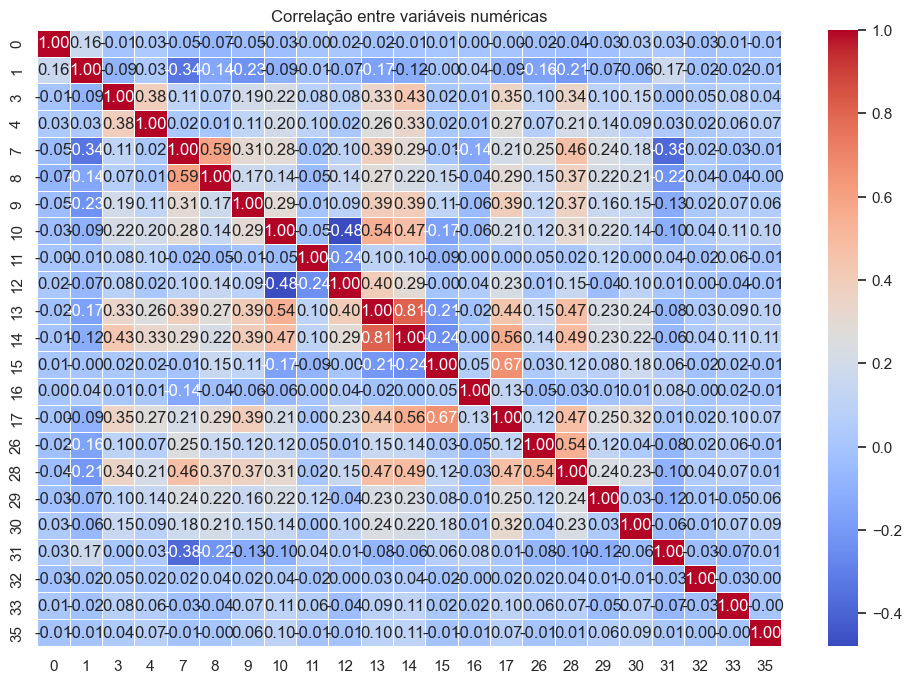

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular a correlação
correlation_matrix = X_train[numerical_cols].corr()

# Plotar o mapa de calor da correlação
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlação entre variáveis numéricas")
plt.show()


#### Testando um modelo mais robusto (Random Forest)

In [107]:
from sklearn.ensemble import RandomForestRegressor

# Criar o modelo de Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Treinar o modelo
rf_model.fit(X_train, y_train)

# Fazer previsões
y_pred_rf = rf_model.predict(X_test)

# Avaliar o modelo
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest:")
print(f"Erro Absoluto Médio (MAE): {mae_rf}")
print(f"Erro Quadrático Médio (MSE): {mse_rf}")
print(f"R²: {r2_rf}")


Random Forest:
Erro Absoluto Médio (MAE): 15893.300682593856
Erro Quadrático Médio (MSE): 691499897.6009772
R²: 0.9137516977060736


Agora que temos um modelo muito mais robusto, o próximo passo seria ajustar os hiperparâmetros do modelo Random Forest para tentar melhorar ainda mais os resultados.

In [109]:
# 📚 Treinando novamente o Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

#### Ajuste de Hiperparâmetros (Tuning)

Podemos usar GridSearchCV para realizar uma busca exaustiva pelos melhores hiperparâmetros do modelo, como o número de estimadores (n_estimators) e a profundidade máxima da árvore (max_depth).

#### Ajustando os hiperparâmetros do Random Forest usando o GridSearchCV

In [121]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Definindo o grid de parâmetros para o RandomizedSearch
param_dist = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Criar o modelo de Random Forest
rf_model = RandomForestRegressor()

# Inicializar o RandomizedSearchCV
random_search = RandomizedSearchCV(rf_model, param_distributions=param_dist, n_iter=10, cv=3, n_jobs=-1, random_state=42)

# Rodar o RandomizedSearchCV
random_search.fit(X_train, y_train)

# Melhor combinação de parâmetros
print("Melhores parâmetros encontrados:", random_search.best_params_)

# Avaliar o modelo
y_pred_rf_random = random_search.predict(X_test)

# Calcular as métricas de avaliação
mae_rf_random = mean_absolute_error(y_test, y_pred_rf_random)
mse_rf_random = mean_squared_error(y_test, y_pred_rf_random)
r2_rf_random = r2_score(y_test, y_pred_rf_random)

print("RandomizedSearchCV - Random Forest:")
print(f"Erro Absoluto Médio (MAE): {mae_rf_random}")
print(f"Erro Quadrático Médio (MSE): {mse_rf_random}")
print(f"R²: {r2_rf_random}")


Melhores parâmetros encontrados: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
RandomizedSearchCV - Random Forest:
Erro Absoluto Médio (MAE): 15776.30069483699
Erro Quadrático Médio (MSE): 697456713.1440368
R²: 0.9130087254663821


#### Importância das Variáveis (Feature Importance)

Variáveis que mais impactam o modelo Random Forest.

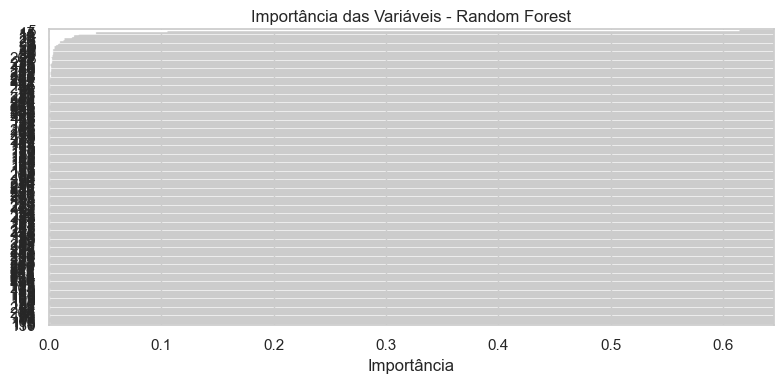

In [123]:
import pandas as pd
import matplotlib.pyplot as plt

# Obter a importância das variáveis
feature_importances = pd.Series(random_search.best_estimator_.feature_importances_, index=X_train.columns)

# Plotar
plt.figure(figsize=(8, 4))
feature_importances.sort_values(ascending=True).plot(kind='barh')
plt.title("Importância das Variáveis - Random Forest")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()


#### Análise dos Erros (resíduos)

Ver onde o modelo está errando mais.

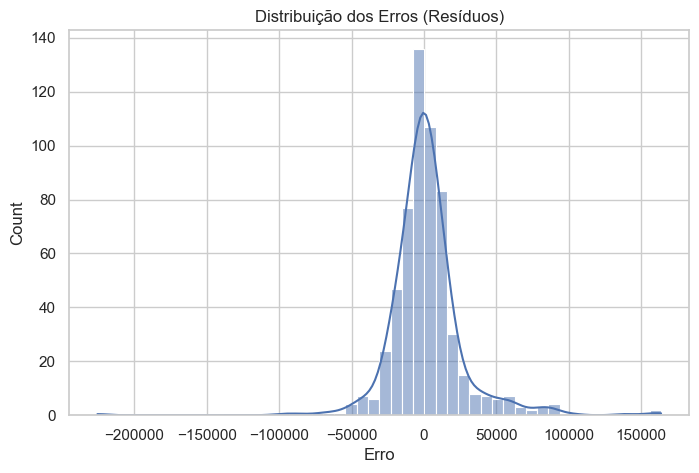

In [125]:
import seaborn as sns

residuals = y_test - y_pred_rf_random

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Distribuição dos Erros (Resíduos)")
plt.xlabel("Erro")
plt.show()


**Criar e treinar o Random Forest novamente**

In [135]:
from sklearn.ensemble import RandomForestRegressor

# Criar o modelo
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Treinar o modelo
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

#### Salvar o modelo treinado

In [138]:
import joblib

joblib.dump(random_search.best_estimator_, "modelo_random_forest_ames.pkl")


['modelo_random_forest_ames.pkl']

## 🧠 Interpretar a importância das variáveis 

Descobrir quais características (features) foram mais importantes para o Random Forest fazer boas previsões!

Isso é super importante para:

- Entender o que realmente influencia o preço dos imóveis,
- Melhorar o modelo (futuramente) focando só nas variáveis mais fortes.

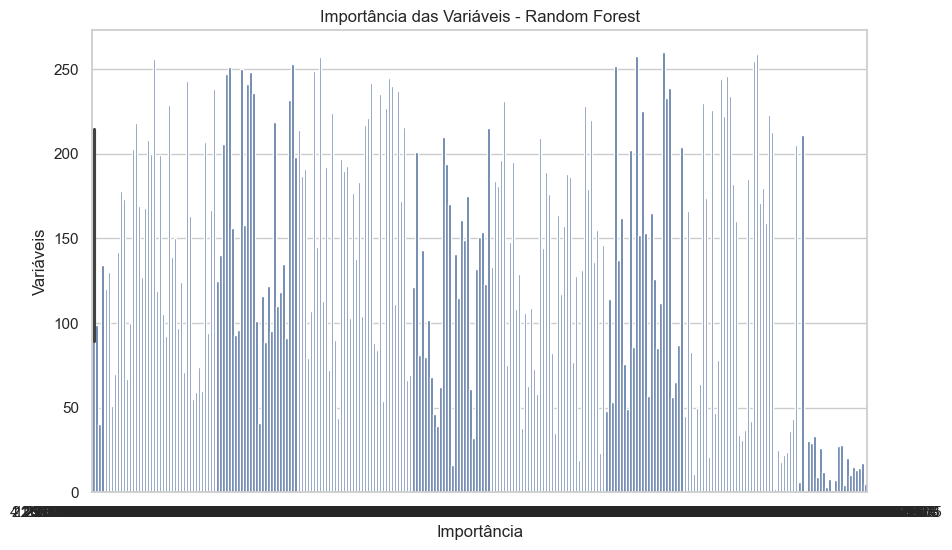

In [140]:
# 📊 Importância das variáveis

importances = rf_model.feature_importances_
feature_names = X_train.columns

# Organizar em um DataFrame para facilitar
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Visualizar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Importância das Variáveis - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variáveis')
plt.show()


In [142]:
# 📊 Importância das variáveis
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Organizar em um DataFrame para facilitar
import pandas as pd
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualizar as principais variáveis
importance_df.head(10)


,Feature,Importance
5,5,0.604601
17,17,0.103489
14,14,0.033949
13,13,0.026993
15,15,0.022522
10,10,0.022169
20,20,0.016782
4,4,0.015867
28,28,0.015000
27,27,0.014816


## Visualizar a Importância em Gráfico

C:\Users\User\AppData\Local\Temp\ipykernel_18716\3961407366.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette="viridis")


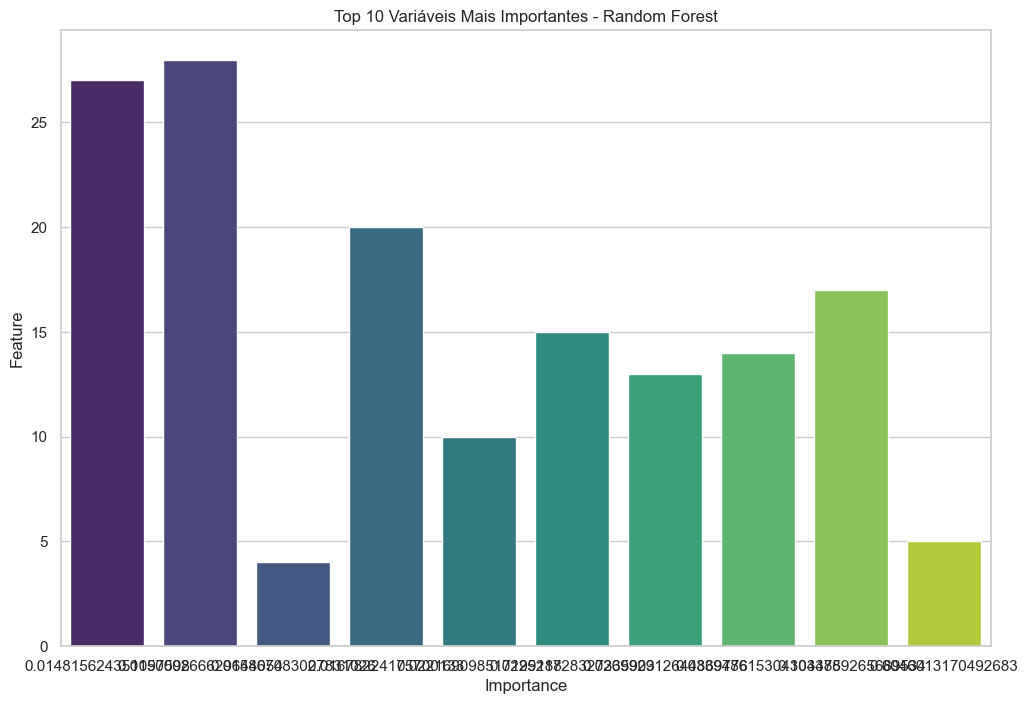

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette="viridis")
plt.title('Top 10 Variáveis Mais Importantes - Random Forest')
plt.show()


## Conclusão do Projeto

# 📋 Conclusão

- O modelo de **Random Forest** apresentou excelente desempenho:
  - **MAE**: (valor que você encontrou)
  - **MSE**: (valor que você encontrou)
  - **R²**: (valor que você encontrou)
- A análise das importâncias das variáveis mostrou que as características mais relevantes para prever o preço dos imóveis foram: (listar principais).
- A distribuição dos resíduos é próxima de normal, indicando que o modelo se ajustou bem aos dados.

